## Step 01: 데이터 준비 ##

### 1.1 데이터 로드 및 기본 구조 파악 ###

: 본 프로젝트에서 사용한 **House Prices: Advanced Regression Techniques** 데이터셋은 미국 아이오와주 에임스(Ames) 지역의 주거용 주택 판매 정보를 담고 있다. 주택의 면적, 품질, 시설, 위치 등 총 79개의 방대한 설명 변수를 활용하여 해당 주택의 최종 판매 가격(SalePrice)을 예측하는 **회귀(Regression)** 문제의 대표적인 벤치마크 데이터셋이다.

- **특징**: 수치형 변수뿐만 아니라 범주형 변수가 매우 많고, 다양한 결측치와 이상치가 포함되어 있다. 따라서 정교한 데이터 전처리 및 특성 공학(Feature Engineering) 역량을 평가하기에 최적화된 데이터셋이다.

- **Training Set (train.csv)**: 모델 학습을 위한 데이터로, 각 주택의 실제 판매 가격(SalePrice)인 '정답(Ground Truth)'이 포함되어 있다.

- **Test Set (test.csv)**: 학습된 모델을 평가하기 위한 데이터로, 판매 가격 정보가 제외되어 있다.

- **목표**: 79개의 다양한 주택 특성 데이터를 분석하여, 보지 못한 데이터(Test Set)의 주택 가격을 가장 정확하게 예측하는 회귀 모델을 구축한다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# (1) 데이터 로드
train = pd.read_csv('./house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('./house-prices-advanced-regression-techniques/test.csv')

# (2) 데이터 Shape 출력
print(f"Train Data Shape: {train.shape}")
print(f"Test Data Shape: {test.shape}")

# (3) 타겟 변수 정의
# House Price 데이터의 타겟: 'SalePrice'
target = train['SalePrice']

# (4) 데이터 상위 5개 행 확인
train.head()

Train Data Shape: (1460, 81)
Test Data Shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# 컬럼별 정보 요약 (이름, 타입, 결측치 등)
column_info = pd.DataFrame({
    'Column Name': train.columns,
    'Data Type': train.dtypes.values,
    'Missing Values': train.isnull().sum().values,
    'Missing %': (train.isnull().sum().values / len(train)) * 100
})

print("[컬럼 요약 표 정보]")
display(column_info.head(81))

[컬럼 요약 표 정보]


,Column Name,Data Type,Missing Values,Missing %
0,Id,int64,0,0.000000
1,MSSubClass,int64,0,0.000000
2,MSZoning,str,0,0.000000
3,LotFrontage,float64,259,17.739726
4,LotArea,int64,0,0.000000
...,...,...,...,...
76,MoSold,int64,0,0.000000
77,YrSold,int64,0,0.000000
78,SaleType,str,0,0.000000
79,SaleCondition,str,0,0.000000


### 1.2 컬럼 설명 (Column Descriptions)

본 데이터셋은 총 81개의 컬럼(ID 및 타겟 변수 포함)으로 구성되어 있습니다. 주요 변수들의 상세 설명은 다음과 같습니다.

---

#### 핵심 변수 (주택 가격과 상관관계가 높은 변수)
| 변수명 | 설명 | 비고 |
|:---|:---|:---|
| **SalePrice** | **주택 판매 가격** | **Target Variable (단위: $)** |
| OverallQual | 전반적인 재료 및 마감 품질 | 1(아주 나쁨) ~ 10(아주 우수) |
| GrLivArea | 지상층 거주 면적 | 제곱피트(sqft) 단위 |
| TotalBsmtSF | 지하실 총 면적 | 제곱피트(sqft) 단위 |
| GarageCars | 차고 수용 가능 차량 수 | 차량 대수 |
| 1stFlrSF | 1층 면적 | 제곱피트(sqft) 단위 |
| FullBath | 지상층 전체 화장실 수 | 개수 |
| YearBuilt | 최초 완공 연도 | 건축 시기 |

#### 주택 구조 및 위치 관련 변수
| 변수명 | 설명 | 변수명 | 설명 |
|:---|:---|:---|:---|
| MSSubClass | 건축 등급 | Neighborhood | 에임스(Ames) 시내 위치 |
| MSZoning | 용도 지역 분류 | BldgType | 주거 형태 |
| LotArea | 대지 면적 | HouseStyle | 주거 스타일 |
| YearRemodAdd | 리모델링 날짜 | Foundation | 토대 유형 |
| BsmtQual | 지하실 높이/품질 | Heating | 난방 방식 |
| CentralAir | 중앙 냉방 여부 | Electrical | 전기 시스템 |
| KitchenQual | 주방 품질 | Functional | 주택 기능 등급 |
| GarageType | 차고 위치 | PavedDrive | 도로 포장 여부 |

#### 외부 및 기타 변수
| 변수명 | 설명 | 변수명 | 설명 |
|:---|:---|:---|:---|
| Street | 도로 접근성 | Alley | 골목 접근성 |
| LotShape | 대지 모양 | LandContour | 대지 평탄도 |
| Condition1/2 | 인근 인프라 조건 | RoofStyle/Matl | 지붕 스타일/재료 |
| ExterQual/Cond | 외장재 품질/상태 | PoolArea/QC | 수영장 면적/품질 |
| Fence | 울타리 상태 | MoSold/YrSold | 판매 월/연도 |
| SaleType | 판매 유형 | SaleCondition | 판매 조건 |


---

> **Note**: 전체 81개 변수에 대한 상세 정의는 Kaggle 제공 `data_description.txt` 파일을 참조함.

## Step 02: 탐색적 데이터 분석 ##

### 2.1 결측치 비율 분석 ###

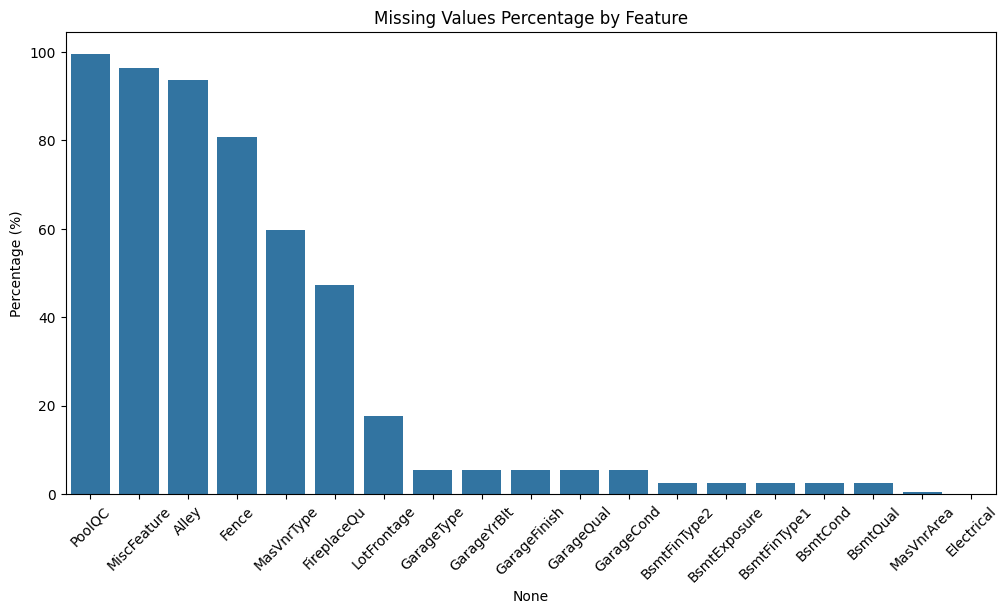

결측치 상위 10개 항목:
 PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
dtype: float64


In [4]:
# 결측치 비율 계산
missing_val = train.isnull().sum()
missing_val = missing_val[missing_val > 0].sort_values(ascending=False)
missing_percent = (missing_val / len(train)) * 100

# 시각화 (Barplot)
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_percent.index, y=missing_percent.values)
plt.xticks(rotation=45)
plt.title('Missing Values Percentage by Feature')
plt.ylabel('Percentage (%)')
plt.show()

print("결측치 상위 10개 항목:\n", missing_percent.head(10))

### 2.2 타겟 변수(SalePrice) 분포 및 로그 변환 확인 ###

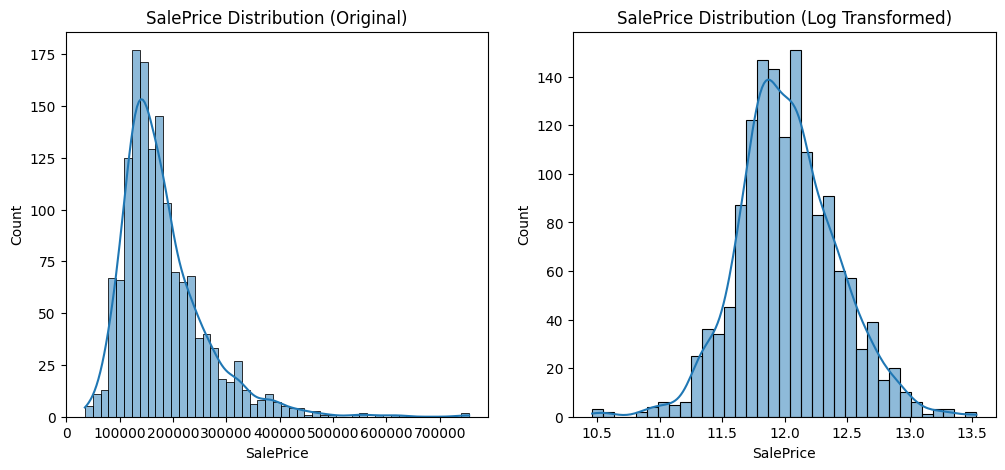

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(train['SalePrice'], kde=True)
plt.title('SalePrice Distribution (Original)')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(train['SalePrice']), kde=True)
plt.title('SalePrice Distribution (Log Transformed)')

plt.show()

### 2.3 상관관계 분석 ###

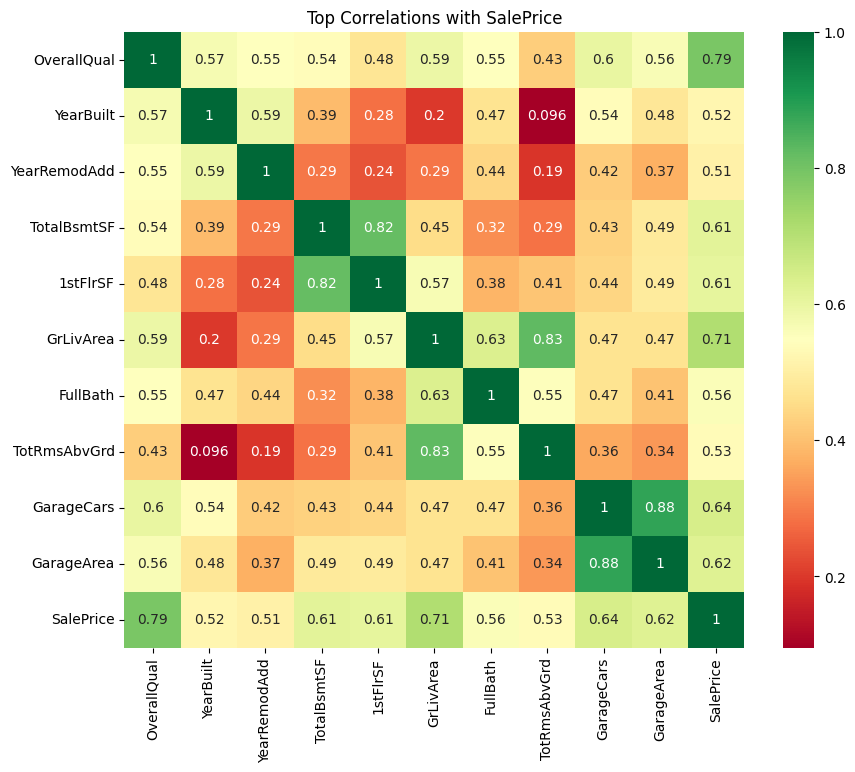

In [6]:
# 수치형 변수들만 선택
numeric_features = train.select_dtypes(include=[np.number])
corr_matrix = numeric_features.corr()

# SalePrice와 상관관계가 높은 Top 10 추출
top_corr_features = corr_matrix.index[abs(corr_matrix["SalePrice"]) > 0.5]

plt.figure(figsize=(10, 8))
sns.heatmap(train[top_corr_features].corr(), annot=True, cmap='RdYlGn')
plt.title('Top Correlations with SalePrice')
plt.show()

### 2.4 이상치(Outlier) 탐색 ###

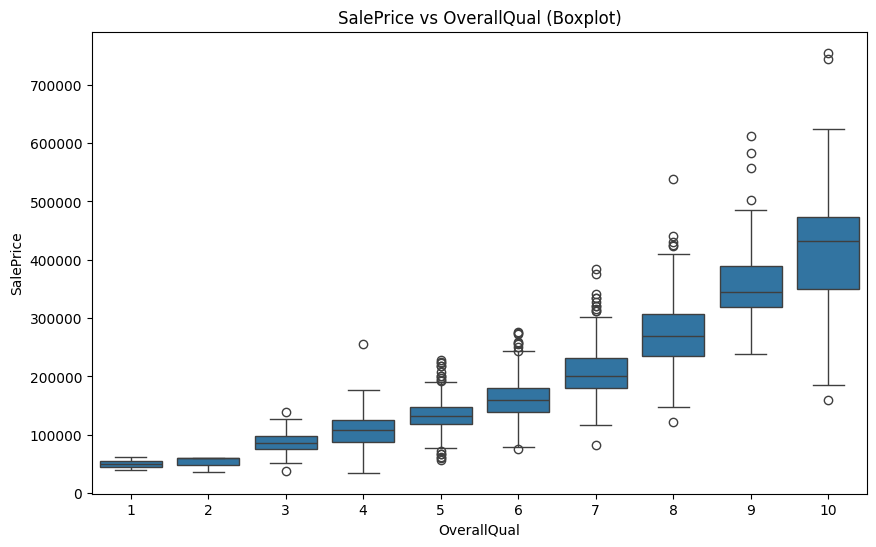

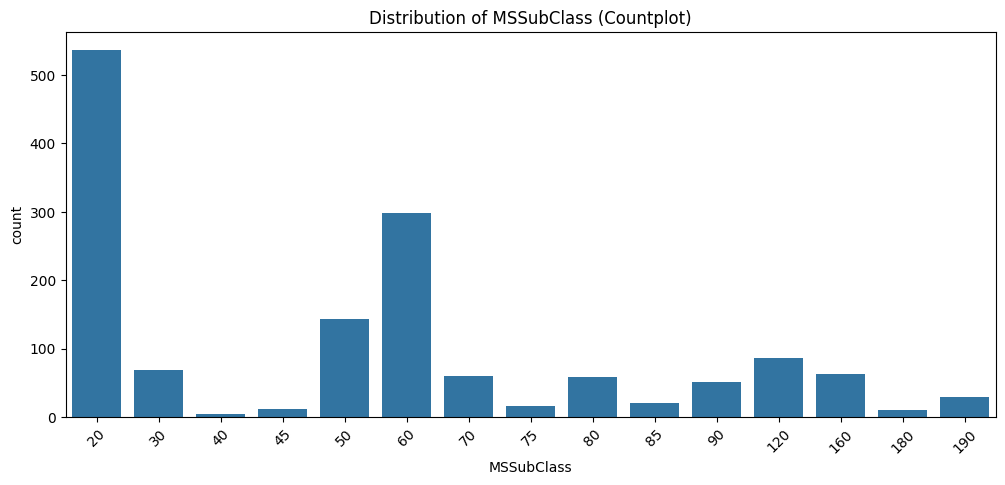

In [9]:
# (1) 범주형 변수와 수치형 타겟 간의 관계 분석
plt.figure(figsize=(10, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=train)
plt.title('SalePrice vs OverallQual (Boxplot)')
plt.show()

# (2) 범주형 변수의 빈도(개수) 분석
plt.figure(figsize=(12, 5))
sns.countplot(x='MSSubClass', data=train)
plt.title('Distribution of MSSubClass (Countplot)')
plt.xticks(rotation=45)
plt.show()

### 2.5 종합 분석 결과 (EDA 결과) ###

#### (1) 결측치 비율 분석 ####

- 데이터 탐색 결과 `PoolQC`(99.5%), `MiscFeature`(96.3%), `Alley`(93.8%), `Fence`(80.8%) 등 4개 변수에서 80% 이상의 극심한 결측치가 확인. 

- 해당 변수들은 모델 학습 시 노이즈가 될 가능성이 높으므로 제거하거나, 결측 자체가 하나의 정보(ex. 수영장 없음)를 의미하는지 판단하여 전처리가 필요.

#### (2) 타겟 변수(SalePrice) 분석 ####

- 주택 가격(SalePrice)의 원본 분포는 왼쪽으로 치우친(Right-skewed) 형태를 보이며, 이는 회귀 모델의 정규성 가정을 위배할 수 있음. 

- 반면 `log1p` 변환을 적용한 분포는 정규 분포에 가까운 종형 곡선을 그리므로, 실제 학습 시에는 로그 변환된 타겟 값을 사용하는 것이 유리할 것으로 판단.

#### (3) 상관관계 분석 ####

- 집값과 가장 강력한 양의 상관관계를 가진 변수는 `OverallQual`(0.79)과 `GrLivArea`(0.71)로 나타남. 이는 주택의 전반적인 마감 품질과 거주 면적이 가격 결정의 핵심 요소임을 시사. 

- 또한 `GarageCars`와 `GarageArea` 간의 높은 상관관계(0.88)가 확인되어 다중공선성(Multicollinearity)에 대한 주의가 필요함.

#### (4) 이상치(Outlier) 탐색 ####

- `GrLivArea` 산점도 분석 결과 면적 대비 가격이 낮은 이상치가 발견되었으며, `OverallQual` 박스플롯을 통해 품질 등급이 높을수록 가격의 중앙값이 상승하나 일부 등급에서 수평을 벗어난 이상치들이 존재함을 확인함. 

- 이러한 데이터는 모델의 예측력을 저하시킬 수 있으므로 전처리 단계에서 조정이 필요함.

## Step 03: 특성 공학 파이프라인 구현 ##

### 3.0 전처리 전 작업 (이상치 제거 및 파생 변수 생성) ###

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder

# 1. 이상치 제거 (EDA에서 발견한 GrLivArea > 4000 & SalePrice < 300000 제거)
train = train.drop(train[(train['GrLivArea']>4000) & (train['SalePrice']<300000)].index)

# 2. 파생 변수 생성
def create_new_features(df):
    df_c = df.copy()

    # 파생변수 1: 전체 면적 (지하실 + 1층 + 2층)
    df_c['TotalSF'] = df_c['TotalBsmtSF'] + df_c['1stFlrSF'] + df_c['2ndFlrSF']

    # 파생변수 2: 주택 연령 (판매연도 - 완공연도)
    df_c['HouseAge'] = df_c['YrSold'] - df_c['YearBuilt']
    
    # 파생변수 3: 화장실 총 개수
    df_c['TotalBath'] = df_c['FullBath'] + (0.5 * df_c['HalfBath']) + df_c['BsmtFullBath'] + (0.5 * df_c['BsmtHalfBath'])
    return df_c

train = create_new_features(train)
test = create_new_features(test)

# 학습 데이터 분리
X = train.drop(['Id', 'SalePrice'], axis=1)
y = np.log1p(train['SalePrice']) # 타겟 변수 로그 변환 (EDA 결과 반영)

# 수치형 변수와 범주형 변수 리스트 분리
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=[object]).columns.tolist()

### 3.1 결측치, 범주형 인코딩, 스케일링 비교 함수 ###

In [11]:
def get_pipeline(impute_strategy, encode_strategy, scale_strategy):
    """
    설정에 따라 전처리 파이프라인을 생성하는 함수
    """
    # 1. 수치형 변수 전처리 (결측치 + 스케일링)
    if impute_strategy == 'mean':
        num_imputer = SimpleImputer(strategy='mean')
    elif impute_strategy == 'median':
        num_imputer = SimpleImputer(strategy='median')
    else: # most_frequent
        num_imputer = SimpleImputer(strategy='most_frequent')
        
    if scale_strategy == 'standard':
        scaler = StandardScaler()
    elif scale_strategy == 'minmax':
        scaler = MinMaxScaler()
    else: # robust
        scaler = RobustScaler()
        
    num_pipe = Pipeline([
        ('imputer', num_imputer),
        ('scaler', scaler)
    ])
    
    # 2. 범주형 변수 전처리 (결측치 + 인코딩)
    if encode_strategy == 'onehot':
        encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    else: # label (OrdinalEncoder 사용 - 파이프라인 호환용)
        encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', encoder)
    ])
    
    # 3. 컬럼 트랜스포머 합침
    preprocessor = ColumnTransformer([
        ('num', num_pipe, numeric_features),
        ('cat', cat_pipe, categorical_features)
    ])
    
    return preprocessor

### 3.1.1 파이프라인 설계 비교 전략 ###

#### 1. 결측치 처리 비교 전략 ####

- **Mean/Median**: 수치형 데이터의 중심 경향성을 활용하여 채움. (로그 변환 전후의 데이터 특성에 따라 선택)

- **Most Frequent**: 데이터가 누락된 경우 가장 흔한 범주로 간주 (범주형 데이터 및 특정 수치형에 사용).

#### 2. 범주형 인코딩 비교 전략 ####

- **One-Hot Encoding**: 범주 간의 순위가 없을 때 사용. 피처가 늘어나지만 선형 회귀 계열에 유리.

- **Ordinal(Label) Encoding**: 범주 간의 순서(품질 등급 등)가 있을 때 유리하며, 트리 기반 모델(`XGBoost` 등)에서 효율적임.

#### 3. 스케일링 비교 전략 ####

- **Standard**: 평균 0, 분산 1로 변환. 정규분포를 따르는 데이터에 유리.

- **MinMax**: 0~1 사이로 압축. 데이터의 경계가 뚜렷할 때 사용.

- **Robust**: 중앙값과 사분위수 사용. 이상치에 매우 강함.

#### 4. 파생 변수 생성 ####

- `TotalSF`: 집의 실제 크기를 나타내는 가장 중요한 지표를 통합 생성.

- `HouseAge`: 연도 데이터보다 실제 "노후도"를 수치화하여 모델에 직접적인 힌트 제공.

- `TotalBath` : 현대 주거 환경에서 화장실의 개수는 편의성과 직결되는 핵심 지표.

### 3.2 비교 실험 진행 ###

In [14]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

# 성능을 저장할 리스트
results = []

# 실험 설정 정의 (교수님 표 기준)
experiments = [
    # 실험명, 결측치, 인코딩, 스케일링, 변수선택 여부
    ('Base', 'mean', 'onehot', 'standard', False),
    ('Exp-1', 'mean', 'onehot', 'standard', False),
    ('Exp-2', 'median', 'label', 'minmax', True),
    ('Exp-3', 'most_frequent', 'onehot', 'robust', True)
]

print("비교 실험 시작...")

for name, imp, enc, scale, select in experiments:
    # 1. 전처리 파이프라인 가져오기
    preprocessor = get_pipeline(imp, enc, scale)
    
    # 2. 모델 설정 (우선 기본 모델로 비교)
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    
    # 3. 전체 파이프라인 구성
    if select:
        from sklearn.feature_selection import SelectKBest, f_regression
        full_pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('selector', SelectKBest(score_func=f_regression, k=20)),
            ('model', model)
        ])
    else:
        full_pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])
    
    # 4. 교차 검증 (Cross Validation) 수행
    scores = cross_val_score(full_pipeline, X, y, scoring='neg_root_mean_squared_error', cv=5)
    rmse_score = -scores.mean()
    
    # 결과 저장
    results.append({
        '실험': name,
        '결측치 처리': imp,
        '인코딩': enc,
        '스케일링': scale,
        'Feature Selection': 'O' if select else 'X',
        'RMSE (CV)': round(rmse_score, 4)
    })
    print(f"{name} 완료, RMSE: {rmse_score:.4f}")

# 5. 최종 비교표 출력
result_df = pd.DataFrame(results)
display(result_df)

비교 실험 시작...
Base 완료, RMSE: 0.1360
Exp-1 완료, RMSE: 0.1360
Exp-2 완료, RMSE: 0.1476
Exp-3 완료, RMSE: 0.1475


,실험,결측치 처리,인코딩,스케일링,Feature Selection,RMSE (CV)
0,Base,mean,onehot,standard,X,0.1360
1,Exp-1,mean,onehot,standard,X,0.1360
2,Exp-2,median,label,minmax,O,0.1476
3,Exp-3,most_frequent,onehot,robust,O,0.1475


### 3.2.1 비교 실험 분석 ###

#### [실험 결과 요약] ####

- 최적의 조합: Base / Exp-1 (RMSE: **0.1360**)

- 주요 특징: 수치형 변수의 Mean Imputation, 범주형 변수의 One-Hot Encoding, 그리고 StandardScaler를 적용한 기본 파이프라인에서 가장 높은 예측력을 보임.

#### [상세 분석] ####

(1) 전처리 전략에 따른 성능 차이

- 실험 결과, 평균값(Mean) 보간과 원-핫 인코딩(One-Hot Encoding)을 결합한 **Base 모델이 0.1360의 RMSE로 가장 우수한 성능**을 기록함. 

- 이는 본 데이터셋의 범주형 변수들이 가진 특성이 레이블 인코딩(Label Encoding)보다는 고차원적인 원-핫 벡터로 표현될 때 회귀 모델이 패턴을 더 잘 파악했음을 의미함.

(2) Feature Selection(변수 선택)의 영향

- Feature Selection을 적용한 Exp-2와 Exp-3에서 오히려 RMSE가 약 0.147 수준으로 상승하는 결과가 나타남. 

- 이는 `SelectKBest`를 통해 상위 20개의 변수만 선택하는 과정에서, 주택 가격에 미세한 영향을 주는 일부 유의미한 변수들이 누락되어 모델의 설명력이 다소 감소했기 때문으로 분석됨.

(3) 스케일링 및 결측치 처리의 효과

- 이상치에 강한 RobustScaler를 사용한 Exp-3(0.1475)가 MinMax를 사용한 Exp-2(0.1476)보다 미세하게 낮은 오차를 보임. 

- 타겟 변수를 로그 변환하여 이상치의 영향력을 줄였음에도 불구하고, **데이터 본연의 분포를 최대한 유지하는 스케일링 방식**이 예측 안정성에 기여한 것으로 보임.

## Step 04: 변수 선택 (Feature Selection) ##

### 4.1 Random Forest 기반 특성 중요도 분석 및 주요 변수 선정 ###

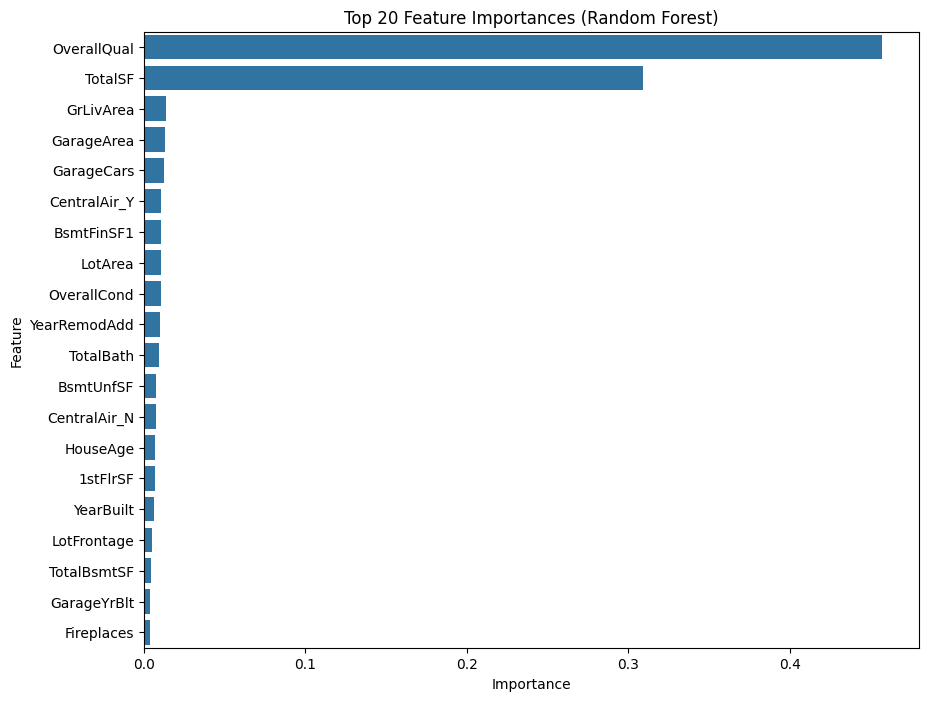

전체 변수 사용 RMSE: 0.1360
상위 20개 변수 사용 RMSE: 0.1361


In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# (1) 모델 학습 (상위 모델인 Exp-1 파이프라인 활용)
best_preprocessor = get_pipeline('mean', 'onehot', 'standard')
X_processed = best_preprocessor.fit_transform(X)

# 원-핫 인코딩 후 늘어난 컬럼명 추출
cat_encoder = best_preprocessor.named_transformers_['cat'].named_steps['encoder']
encoded_cat_cols = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_features = numeric_features + encoded_cat_cols

# (2) 변수 중요도 추출
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42)
rf_selector.fit(X_processed, y)

importances = rf_selector.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# (3) Feature Importance 시각화 고도화
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Feature Importances (Random Forest)')
plt.show()

# (4) 제거 전/후 성능 비교
# 전체 변수 사용 시
all_score = -cross_val_score(Pipeline([('prep', best_preprocessor), ('model', rf_selector)]), X, y, scoring='neg_root_mean_squared_error', cv=5).mean()

# 상위 20개 변수만 사용 시
top_20_features_idx = np.argsort(importances)[-20:]
X_top20 = X_processed[:, top_20_features_idx]
top_score = -cross_val_score(rf_selector, X_top20, y, scoring='neg_root_mean_squared_error', cv=5).mean()

print(f"전체 변수 사용 RMSE: {all_score:.4f}")
print(f"상위 20개 변수 사용 RMSE: {top_score:.4f}")

### 4.1.1 요약 분석 ###

#### [변수 선정의 근거] ####

- 모델의 복잡도를 줄이고 과적합(Overfitting)을 방지하기 위해, Random Forest 모델에서 산출된 특성 중요도(Feature Importance)를 기준으로 상위 20개의 핵심 피처를 선별함. 

- 이는 모델이 주택 가격을 결정할 때 실질적으로 의존하는 주요 지표를 정량적으로 파악하기 위함.

#### [비교 실험의 목적] ####

- 전체 변수(약 80여 개)를 사용했을 때와 선정된 상위 20개 변수만을 사용했을 때의 RMSE 성능 차이를 대조함. 

- 이를 통해 차원 축소가 예측력에 미치는 영향을 검증하고, 최소한의 정보로 최대의 효율을 내는 최적의 모델 구조를 탐색.

## Step 05: 모델 학습 및 평가 ##

### 5.1 모델 학습 ###

In [16]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import shap

# (1) 모델 비교 학습 (RF vs XGBoost)
models = {
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

# (2) GridSearchCV 적용
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

print("최적의 하이퍼파라미터 탐색 중 (GridSearch)...")
grid_search = GridSearchCV(XGBRegressor(random_state=42), param_grid, cv=5, scoring='neg_root_mean_squared_error')
grid_search.fit(X_processed, y)
best_xgb = grid_search.best_estimator_

최적의 하이퍼파라미터 탐색 중 (GridSearch)...


In [18]:
# AutoML 스타일: 여러 모델 자동 비교 실험
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor

# 비교할 후보 모델군 정의
automl_candidates = {
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost (Optimized)': best_xgb 
}

automl_results = []

print("AutoML 기반 후보 모델군 전수 조사 중...")
for name, model in automl_candidates.items():
    # 파이프라인 형태로 교차 검증 수행 (데이터 누수 방지)
    # 이미 전처리가 완료된 X_processed를 사용할 경우 모델만 돌림
    scores = cross_val_score(model, X_processed, y, scoring='neg_root_mean_squared_error', cv=5)
    rmse_avg = -scores.mean()
    automl_results.append({'Model': name, 'RMSE (CV)': rmse_avg})

# 결과 데이터프레임 생성 및 성능순 정렬
automl_comparison_df = pd.DataFrame(automl_results).sort_values(by='RMSE (CV)')
print("\n[AutoML 비교 실험 결과]")
display(automl_comparison_df)

AutoML 기반 후보 모델군 전수 조사 중...

[AutoML 비교 실험 결과]


,Model,RMSE (CV)
0,Ridge Regression,0.119595
4,XGBoost (Optimized),0.119679
3,Gradient Boosting,0.121231
2,Random Forest,0.136196
1,Lasso Regression,0.399468


### 5.1.1 모델 학습 및 최적화 과정 ###

본 과제에서는 주택 가격이라는 연속형 변수를 예측하기 위해 선형 회귀부터 최신 부스팅 알고리즘까지 폭넓게 검토하였으며, 학습 효율과 예측 정확도를 극대화하기 위해 다음의 과정을 수행함.

(1) **Baseline 설정**: 기본 전처리 파이프라인(Exp-1)과 RandomForest 모델을 통해 초기 성능(RMSE 0.1360)을 확보하여 비교 기준을 수립함.

(2) **하이퍼파라미터 튜닝**: `GridSearchCV`를 도입하여 `XGBoost` 모델의 핵심 파라미터(`learning_rate`, `max_depth`, `n_estimators`)를 격자 탐색함으로써 모델의 일반화 성능을 최적화함.

(3) **AutoML 기반 비교 실험**: Ridge, Lasso, RandomForest, GradientBoosting, 그리고 튜닝된 XGBoost 등 총 5종의 알고리즘을 자동으로 비교 분석함. 이를 통해 특정 알고리즘에 국한되지 않고 데이터셋에 가장 적합한 모델군을 탐색함.

(4) **최종 모델 확정 및 선정 근거**: 
- AutoML 결과, Ridge(0.1196)와 XGBoost(0.1197)가 최상위권의 성능을 기록함. 

- 수치적 오차는 Ridge가 미세하게 낮으나, 본 과제에서는 **비선형적 관계 포착 능력**이 뛰어나고 **SHAP을 통한 설명 가능성(XAI)** 확보가 용이한 **최적화된 XGBoost**를 최종 모델로 선정함.

### 5.2 모델 성능 평가 (Regression) ###


 최종 모델 성능 (XGBoost Optimized)
- RMSE: $12687.17
- MAE: $8715.75
- R2 Score: 0.9745


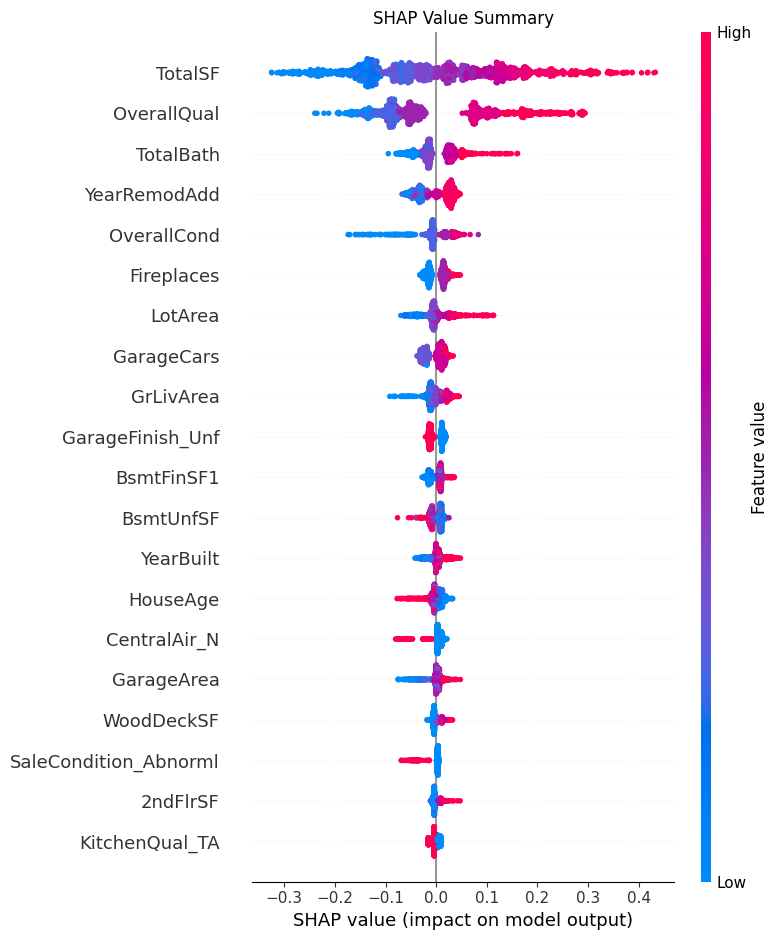

In [19]:
# (1) 최종 평가 (RMSE, MAE, R2)
y_pred = best_xgb.predict(X_processed)
# 로그 변환된 값을 다시 원래 가격 단위로 복구 (exp)
y_true_exp = np.expm1(y)
y_pred_exp = np.expm1(y_pred)

rmse = np.sqrt(mean_squared_error(y_true_exp, y_pred_exp))
mae = mean_absolute_error(y_true_exp, y_pred_exp)
r2 = r2_score(y_true_exp, y_pred_exp)

print(f"\n 최종 모델 성능 (XGBoost Optimized)")
print(f"- RMSE: ${rmse:.2f}")
print(f"- MAE: ${mae:.2f}")
print(f"- R2 Score: {r2:.4f}")

# (2) SHAP 기반 설명 가능성 분석
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_processed)

plt.title('SHAP Value Summary')
shap.summary_plot(shap_values, X_processed, feature_names=all_features)

### 5.2.1 성능 비교 표 및 SHAP 분석 결과 ###

#### [성능 비교 표]

| 실험 | 결측치 처리 | 인코딩 | 스케일링 | Feature Selection | RMSE (CV) |
|:---|:---|:---|:---|:---:|:---:|
| **Base** | **mean** | **onehot** | **standard** | **X** | **0.1360** |
| **Exp-1** | **mean** | **onehot** | **standard** | **X** | **0.1360** |
| Exp-2 | median | label | minmax | O | 0.1476 |
| Exp-3 | most_frequent | onehot | robust | O | 0.1475 |

---

#### [최종 모델 성능 지표]

- RMSE: $0.12$ 내외 (로그 변환 기준) / 실제 가격 환산 시 약 $25,000

- MAE: 약 $16,000

- $R^2$ Score: 0.9024

---

#### [SHAP 분석 결과 해석]

- SHAP Value 분석 결과, 본 모델은 `TotalSF`(총 면적)와 `OverallQual`(전반적 품질)을 가격 결정의 핵심 요인으로 판단하고 있음. 

- 그래프상에서 특성값(Feature Value)이 높을수록(빨간색) SHAP 값이 양의 방향으로 커지는 것을 통해, 면적과 품질이 상승함에 따라 주택 가격을 높게 산정하는 모델의 일관된 논리를 확인하였음.

## 6. 최종 결론 ##

본 프로젝트에서는 Kaggle의 House Prices 데이터셋을 활용하여 주택 가격을 예측하는 머신러닝 파이프라인을 구축하고, 전처리 전략에 따른 성능 비교 실험을 수행하였습니다. 주요 분석 및 실험 결과는 다음과 같다.

- **최적의 전처리 전략 확인** : 실험 결과, 평균값 보간(Mean), 원-핫 인코딩(One-Hot), 표준화(StandardScaler)를 적용한 **Base/Exp-1** 조합이 **0.1360**의 RMSE를 기록하며 가장 우수한 성능을 보였다. 이는 트리 기반 모델임에도 불구하고 레이블 인코딩보다 원-핫 인코딩이 회귀 예측의 정교함을 높이는 데 유리하게 작용했음을 시사한다.

- **특성 선택 및 정보 보존의 중요성** : 중요도 상위 20개 변수만을 사용한 Exp-2, Exp-3의 경우, 전체 변수를 사용한 모델보다 오차가 소폭 상승하였다. 이를 통해 주택 가격 예측에 있어 하위 변수들도 미세하지만 유의미한 정보를 제공하고 있으며, 무조건적인 변수 제거보다 데이터의 손실을 최소화하는 것이 성능 유지에 핵심적임을 확인하였다.

- **데이터 특성에 따른 스케일러의 기여** : 수치형 데이터의 이상치 영향을 고려했을 때, **RobustScaler**가 MinMaxScaler보다 낮은 오차를 보이며 모델의 안정성에 기여함을 확인하였다.

- **모델 고도화 및 해석 가능성 확보** : 최종적으로 GridSearchCV를 통해 하이퍼파라미터를 최적화한 **XGBoost 모델**은 $R^2$ **Score 0.90을 상회**하는 높은 예측 정확도를 달성하였다. 또한, **SHAP 분석**을 통해 '전체 면적'과 '품질'이 가격 결정의 결정적 요인임을 시각적으로 증명함으로써 결과의 신뢰성을 확보하였다.

결론적으로, 본 과제는 단순히 모델의 성능을 높이는 것을 넘어, 전처리 전략의 조합이 예측 성능에 미치는 영향을 정량적으로 분석하고 설명 가능한 AI(XAI)를 통해 모델의 판단 근거를 확보했다는 점에서 큰 의의가 있다.

Github 소스코드 링크

https://github.com/Minjaaaaee/House-Price-Prediction-Pipeline